In [11]:
import sys
sys.path.append('..')

import os

import glob
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, f1_score

from src.models import RobustDetector
from src.utils import get_freqs, get_freqs_mask

In [12]:
##TRAIN
train_tag  = "attack"
gen_train_model = "udio_v120"

##TEST
attack = None
gen_test_model = "udio_v120"

CKPT_PATH     = f"../checkpoints/sonics/{train_tag}/{gen_train_model}/robustdetector-sonics-log_stft-use_conv-lamb=0.1.ckpt"
BASE_DATA_DIR = "../data/sonics"
SEED          = 42

In [13]:
# Derive DATA_DIR from attack setting
if attack is None:
    DATA_DIR = os.path.join(BASE_DATA_DIR, "noattack", "test")
else:
    DATA_DIR = os.path.join(BASE_DATA_DIR, "attack", "test", attack)

# Derive output name from ckpt path + attack setting
ckpt_parts = CKPT_PATH.replace("\\", "/").split("/")

for part in ckpt_parts:
    if part == "noattack":
        train_tag = "train_noattack"
        break
    if part == "attack":
        train_tag = "train_attack"
        break

test_tag    = f"test_noattack_{gen_test_model}" if attack is None else f"test_attack_{attack}_{gen_test_model}"
OUTPUT_PATH = f"../outputs/{train_tag}_{test_tag}.png"

print(f"DATA_DIR    : {DATA_DIR}")
print(f"OUTPUT_PATH : {OUTPUT_PATH}")

DATA_DIR    : ../data/sonics/noattack/test
OUTPUT_PATH : ../outputs/train_attack_test_noattack_udio_v120.png


In [14]:
torch.manual_seed(SEED)
np.random.seed(SEED)

model = RobustDetector.load_from_checkpoint(CKPT_PATH)
model.eval()
device = torch.device('cpu')
model = model.to(device)

mode = model.transform_type if not model.log_stft else 'stft'
print(f"Model loaded | transform={model.transform_type} | log_stft={model.log_stft} | use_conv={model.use_convolution}")

Model loaded | transform=stft | log_stft=True | use_conv=True


In [15]:
# Load all test fakeprints (no subsampling — unconstrained tracks)
SF_LO, SF_HI = 0.7, 1.4

def load_class(data_dir, label, model):
    freqs = get_freqs(n_fft=model.n_fft, sr=model.sampling_rate,
                      log=(model.transform_type == 'cqt'),
                      bins_per_octave=model.bins_per_octave)
    mask = get_freqs_mask(freqs, model.sampling_rate, model.freq_range)

    fps, speed_factors = [], []
    subdir = gen_test_model if label == 1 else 'human'
    for path in sorted(glob.glob(f"{data_dir}/{subdir}/*.npz")):
        d = np.load(path)
        fp = d[model.transform_type]  # (N, n_bins)
        fp = fp[:, mask]
        sf = d.get('speed_factors', np.ones(len(fp)))
        valid = ~(np.isnan(fp).any(axis=1) | np.isinf(fp).any(axis=1))
        fps.append(fp[valid])
        speed_factors.append(sf[valid])
    concat_sf = np.concatenate(speed_factors)
    print(f"[{subdir}] Number of different speed factors: {len(np.unique(concat_sf))}")
    return np.concatenate(fps), concat_sf

ai_fp, ai_sf = load_class(DATA_DIR, 1, model)
hu_fp, hu_sf = load_class(DATA_DIR, 0, model)

print()
print(f"Speed factor range [HUMAN]: {hu_sf.min():.3f}, {hu_sf.max():.3f}")
print(f"Speed factor range [AI]: {ai_sf.min():.3f}, {ai_sf.max():.3f}")

# Full test tensors: all AI rows first, then all human (same order as before)
n_ai = len(ai_fp)
n_hu = len(hu_fp)
fps = np.concatenate([ai_fp, hu_fp])
labels = np.concatenate([np.ones(n_ai), np.zeros(n_hu)])
sfs = np.concatenate([ai_sf, hu_sf])

m_sf = (sfs >= SF_LO) & (sfs <= SF_HI)
print()
print(f"Unconstrained test set: {n_ai} AI + {n_hu} Human = {n_ai + n_hu} total")
print(f"Samples with {SF_LO} <= speed factor <= {SF_HI}: {m_sf.sum()} "
      f"(AI: {(m_sf & (labels == 1)).sum()}, Human: {(m_sf & (labels == 0)).sum()})")

[udio_v120] Number of different speed factors: 1
[human] Number of different speed factors: 1

Speed factor range [HUMAN]: 1.000, 1.000
Speed factor range [AI]: 1.000, 1.000

Unconstrained test set: 1858 AI + 2572 Human = 4430 total
Samples with 0.7 <= speed factor <= 1.4: 4430 (AI: 1858, Human: 2572)


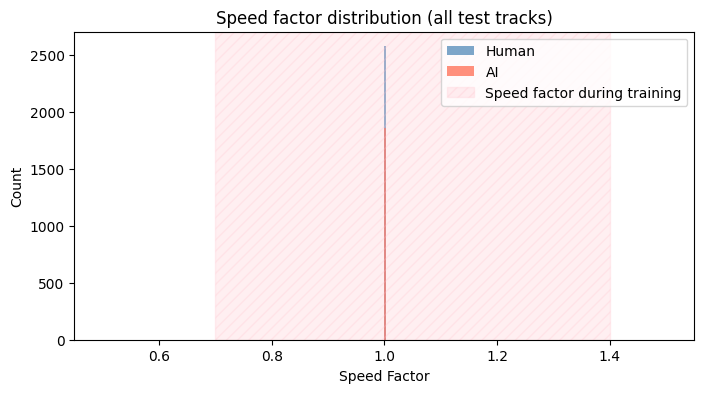

In [16]:
# Speed-factor histograms (full test set)
plt.figure(figsize=(8, 4))
plt.hist(hu_sf, bins=500, alpha=0.7, label='Human', color='steelblue')
plt.hist(ai_sf, bins=500, alpha=0.7, label='AI', color='tomato')
plt.xlabel('Speed Factor')
plt.ylabel('Count')
plt.title('Speed factor distribution (all test tracks)')
ax = plt.gca()
zone = ax.axvspan(SF_LO, SF_HI, color='pink', alpha=0.25, hatch='///', label="Speed factor during training")

plt.legend()
plt.show()

In [17]:
# Inference on all test tracks (single forward pass; filter by speed factor downstream)
with torch.inference_mode():
    x = torch.from_numpy(fps).float().to(device)
    if model.log_stft:
        x = model.stft_to_log(x)
    logits, _ = model(x, convolve=model.use_convolution)
    probs = torch.sigmoid(logits).squeeze(-1).cpu().numpy()

print(f"Probs range (all tracks): [{probs.min():.3f}, {probs.max():.3f}]")

Probs range (all tracks): [0.005, 1.000]


In [18]:
# Classification score distribution: speed factor in [SF_LO, SF_HI] only
probs_sf = probs[m_sf]
labels_sf = labels[m_sf]

# Optimal threshold via F1
thresholds = np.linspace(0, 1, 201)
f1_scores = [f1_score(labels_sf, probs_sf >= t, zero_division=0) for t in thresholds]
best_t = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)
print(f"Optimal threshold: {best_t:.3f}  |  Best F1: {best_f1:.4f}")

Optimal threshold: 0.665  |  Best F1: 0.9906


Saved → ../outputs/train_attack_test_noattack_udio_v120.png


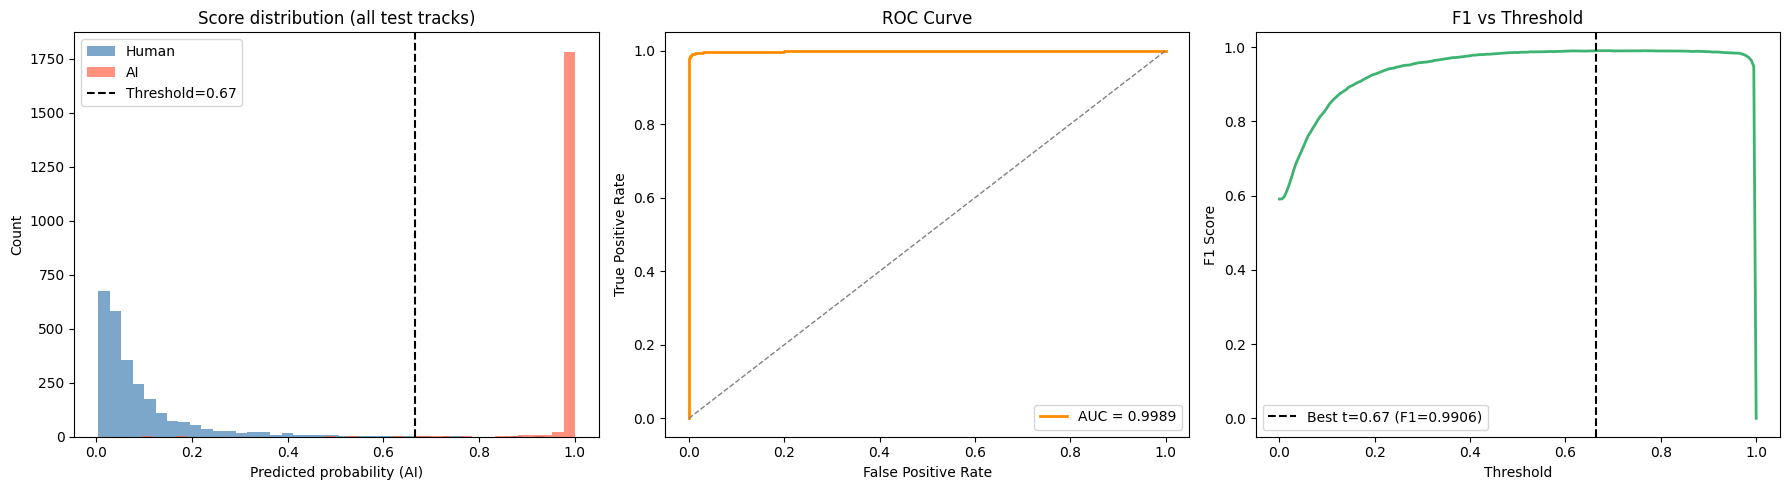

In [19]:
fpr, tpr, _ = roc_curve(labels_sf, probs_sf)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 1. Classification histogram ---
ax = axes[0]
ax.hist(probs_sf[labels_sf == 0], bins=40, alpha=0.7, label='Human', color='steelblue')
ax.hist(probs_sf[labels_sf == 1], bins=40, alpha=0.7, label='AI',    color='tomato')
ax.axvline(best_t, color='black', linestyle='--', linewidth=1.5, label=f'Threshold={best_t:.2f}')
ax.set_xlabel('Predicted probability (AI)')
ax.set_ylabel('Count')
ax.set_title('Score distribution (all test tracks)')
ax.legend()

# --- 2. ROC / AUC ---
ax = axes[1]
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
ax.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()

# --- 3. F1 vs Threshold ---
ax = axes[2]
ax.plot(thresholds, f1_scores, color='mediumseagreen', lw=2)
ax.axvline(best_t, color='black', linestyle='--', linewidth=1.5, label=f'Best t={best_t:.2f} (F1={best_f1:.4f})')
ax.set_xlabel('Threshold')
ax.set_ylabel('F1 Score')
ax.set_title('F1 vs Threshold')
ax.legend()

plt.tight_layout()
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)
plt.savefig(OUTPUT_PATH, dpi=150, bbox_inches="tight")
print(f"Saved → {OUTPUT_PATH}")
plt.show()

/var/folders/15/bg2nr2kn78l2251qrjqx9r2c0000gn/T/ipykernel_29779/4273523427.py:27: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  zone = ax.axvspan(


Saved → ../outputs/f1_vs_sf_train_attack_test_noattack_udio_v120.png


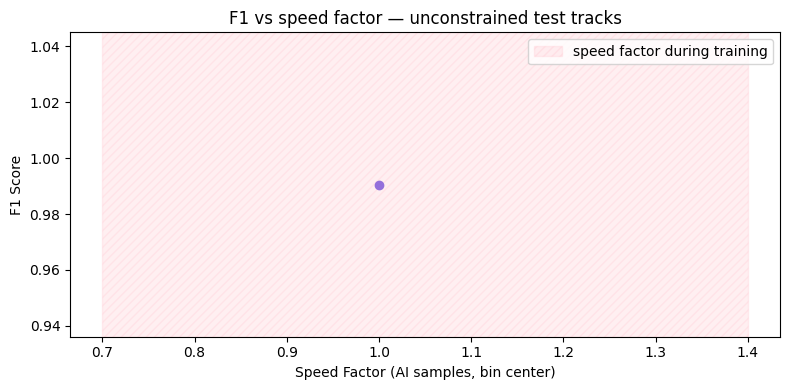

In [20]:
# F1 vs speed factor (unconstrained / all test tracks)
ai_probs = probs[:n_ai]
ai_sfs = sfs[:n_ai]
hu_probs = probs[n_ai:]

sf_min, sf_max = float(ai_sfs.min()), float(ai_sfs.max())
if sf_max <= sf_min:
    sf_max = sf_min + 1e-9
bins = np.linspace(sf_min, sf_max, 15)
bin_centers, bin_f1s = [], []
for i in range(len(bins) - 1):
    lo, hi = bins[i], bins[i + 1]
    mask_ai = (ai_sfs >= lo) & (ai_sfs < hi) if i < len(bins) - 2 else (ai_sfs >= lo) & (ai_sfs <= hi)
    k = int(mask_ai.sum())
    if k < 5:
        continue
    p_bin = np.concatenate([ai_probs[mask_ai], hu_probs])
    l_bin = np.concatenate([np.ones(k), np.zeros(len(hu_probs))])
    f1_b = f1_score(l_bin, p_bin >= best_t, zero_division=0)
    bin_centers.append((lo + hi) / 2)
    bin_f1s.append(f1_b)

fig, ax = plt.subplots(figsize=(8, 4))

# Add the hatched and labeled zone for "speed factor during training"
train_sf_min, train_sf_max = SF_LO, SF_HI
zone = ax.axvspan(
    train_sf_min, train_sf_max,
    color='pink', alpha=0.25, zorder=0,
    hatch='////', edgecolor='crimson', label='speed factor during training'
)

ax.plot(bin_centers, bin_f1s, marker='o', color='mediumpurple', lw=2, zorder=2)

ax.set_xlabel('Speed Factor (AI samples, bin center)')
ax.set_ylabel('F1 Score')
ax.set_title('F1 vs speed factor — unconstrained test tracks')
handles, labels = ax.get_legend_handles_labels()
# Remove any duplicate labels (for legend clarity)
from collections import OrderedDict
by_label = OrderedDict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())
plt.tight_layout()

import os

# Compute the output path, prefixing filename with "f1_vs_sf_"
base_dir = os.path.dirname(OUTPUT_PATH)
original_name = os.path.basename(OUTPUT_PATH)
out_fname = "f1_vs_sf_" + original_name
out_path = os.path.join(base_dir, out_fname)

os.makedirs(base_dir, exist_ok=True)
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved → {out_path}")

plt.show()